# Classifiers for Biochemistry Data
We will again use the ProMelt protein melthing temperature dataset as an example. This has a quantification of mellthing temperature, which we will turn into a classification by setting a threshold for stable or unstable. The file we will use is full_promelt_seq.csv. The source of this data is available here: https://zenodo.org/records/20067528 and is associated with the following paper: Pailozian, et al. Investigation of Protein Melting Temperature Prediction with Cross-Method Validation on Biophysical Data. bioRxiv, 2026. https://doi.org/10.64898/2026.05.07.723192

# Install packages
Only run if you do not already have these packages

In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install matplotlib

# Load and featurize data
We will use the length of th esequence and the counts of certain amino acids as the features. Try different amino acids and see how the accuracy changes.

In [1]:
import pandas as pd
import numpy as np

#counts the number of times an amino acid occurs in the sequence
def count_amino_acid(seq, amino_acid):
    return seq.count(amino_acid)

df = pd.read_csv("full_promelt_seq.csv")

#this will use the string count function on all items in the sequence column (similar to the apply we covered before)
df["Q_frac"] = df["sequence"].str.count('Q')/df["Length"] 
df["E_frac"] = df["sequence"].str.count('E')/df["Length"]
df["G_frac"] = df["sequence"].str.count('G')/df["Length"]


#let's define stable as an unusally stable protein
#most organisms do not encounter high temperatures so we can set a relatively high threshold for the temperature
df['stable'] = df["Tm"] > 55
df

,ProteinID,Organism,Tm,Method,cluster#,cluster_count,Length,sequence,Q_frac,E_frac,G_frac,stable
0,I1W5V5,Oleispira antarctica,38.47000,Meltome/TPP,2524,10,279,MSIENLSSNKSFGGWHKQYSHVSNTLNCAMRFAIYLPPQASTGAKV...,0.043011,0.060932,0.071685,False
1,R4YJ85,Oleispira antarctica,37.96000,Meltome/TPP,6917,1,545,MINLEKALAGRRILIVDDLVEARSSLKKMATILGGDNIDVATDGIE...,0.047706,0.075229,0.036697,False
2,R4YJ88,Oleispira antarctica,51.24000,Meltome/TPP,15606,1,215,MIRRIVASAAILFASFNSFAADNHDHQEAPIADMSKAYTLLDQPQA...,0.055814,0.060465,0.060465,False
3,R4YJ93,Oleispira antarctica,41.36000,Meltome/TPP,15607,1,330,MKLRFSRSSLNLIIFTCIILIGWASIDANINKQHTEDSRKTEIIVL...,0.096970,0.057576,0.033333,False
4,R4YJ97,Oleispira antarctica,41.99000,Meltome/TPP,0,1,397,MPEHIPADSVGIISPKVQRFDEPLTLRSGRILESYELIYETYGELN...,0.040302,0.052897,0.078086,False
...,...,...,...,...,...,...,...,...,...,...,...,...
41541,S7URD1,Toxoplasma gondii,51.87692,TPP/ProTherm,13796,1,929,MRGPLGRGAGGGVASDDRTRGMSDLGKSFQPDGPPTPPDTPHRNFI...,0.039828,0.095802,0.087191,False
41542,S7UX19,Toxoplasma gondii,49.01177,TPP/ProTherm,6914,1,1540,MQQSYPHRYPAPACNGDMQAGSPPQQQVQQYGTSPAAVSQIPALEF...,0.057792,0.056494,0.090260,False
41543,S7UYZ6,Toxoplasma gondii,43.12291,TPP/ProTherm,6915,1,355,MVDYSKWERLQVSSSDEEEAGGKPRVRRFEEKQRVTVGPEGVFIEG...,0.042254,0.143662,0.081690,False
41544,S7UHE6,Toxoplasma gondii,58.30436,TPP/ProTherm,13798,1,584,MDAEETNLGFLVAAHPQRLRRWHFPSKVGGKPEWMETRRLPKTEDL...,0.042808,0.140411,0.075342,True


# Split data into training and test
We will split our data into training and test data. We will do this randomly for now. Note that for testing that better assesses model generlizability, you would want to split so that similar sequences end up in the same split.

In [2]:
from sklearn.model_selection import train_test_split

#this will put 20% of the data into the test set
#note that the random state needs to be set to make sure it is split consistently between runs
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Logistic Regression model

Train Accuracy:  0.7531
Train Precision: 0.5770
Train Recall:    0.0285
Train Balanced Accuracy:    0.0285
AUPRC (Average Precision): 0.4117
AUROC: 0.6678


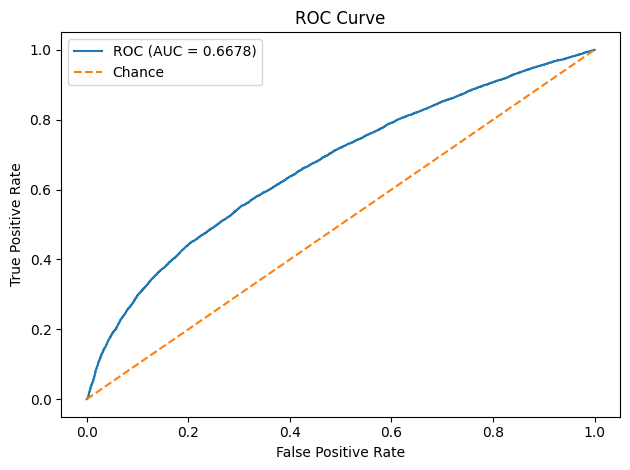

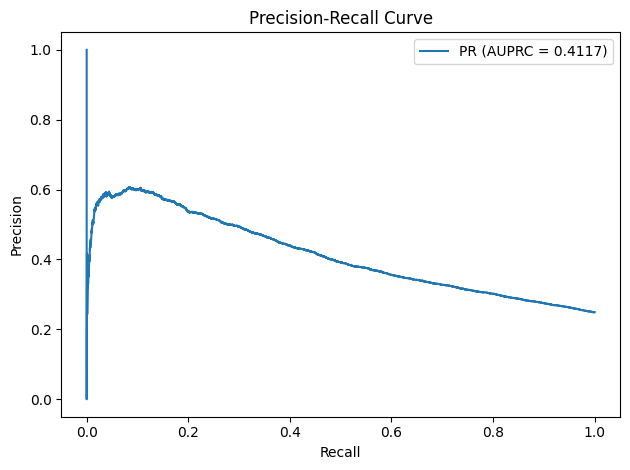

In [3]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
    roc_curve,
    auc,
    precision_recall_curve,
    roc_auc_score
)

# Try logistic regression using selected amino acid counts and lenghts as features
log_classifier = LogisticRegression()
# For scikit learn, fit them to data using the fit function, then list x data or y data
# the x and y data could be matrices you have already prepared or you can extract the columns from a pandas dataframe, as shown
log_classifier.fit(train_df[["Q_frac","E_frac","G_frac","Length"]],train_df["stable"])

# Let's calculate metrics for our training data
predicted_train = log_classifier.predict(train_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels
predicted_train_prob = log_classifier.predict_proba(train_df[["Q_frac","E_frac","G_frac","Length"]]) #this will give probabilities

acc = accuracy_score(train_df["stable"], predicted_train)
prec = precision_score(train_df["stable"], predicted_train, zero_division=0)
rec = recall_score(train_df["stable"], predicted_train, zero_division=0)
balanced_acc = balanced_accuracy_score(train_df["stable"], predicted_train)
fpr, tpr, _ = roc_curve(train_df["stable"], predicted_train_prob[:,1])
roc_auc = roc_auc_score(train_df["stable"], predicted_train_prob[:,1])

#these metrics use probabilities rather than class
auprc = average_precision_score(train_df["stable"], predicted_train_prob[:,1])
    

print(f"Train Accuracy:  {acc:.4f}")
print(f"Train Precision: {prec:.4f}")
print(f"Train Recall:    {rec:.4f}")
print(f"Train Balanced Accuracy:    {rec:.4f}")
print(f"AUPRC (Average Precision): {auprc:.4f}")
print(f"AUROC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall
pr_prec, pr_rec, _ = precision_recall_curve(train_df["stable"], predicted_train_prob[:,1])

plt.figure()
plt.plot(pr_rec, pr_prec, label=f"PR (AUPRC = {auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

Test Accuracy:  0.7569
Test Precision: 0.6058
Test Recall:    0.0309
Test Balanced Accuracy:    0.0309
AUPRC (Average Precision): 0.4189
AUROC: 0.6763


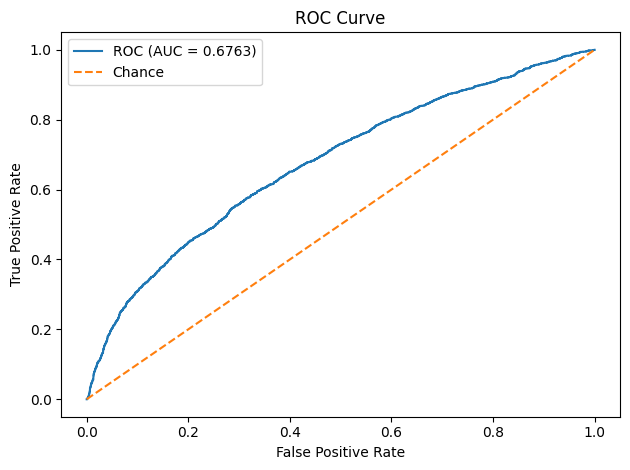

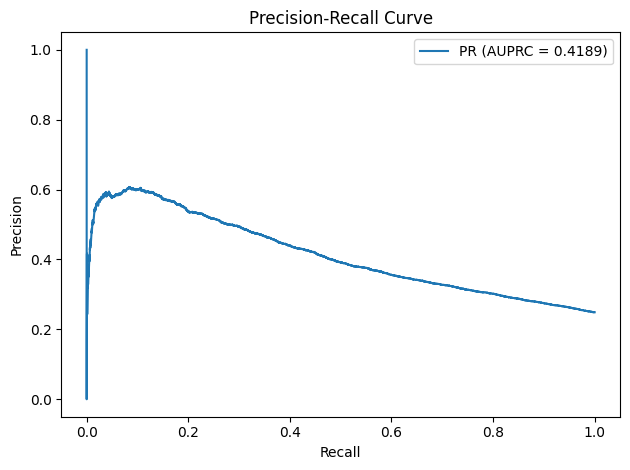

In [4]:
# lets look at the test accuracy
predicted_test = log_classifier.predict(test_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels
predicted_test_prob = log_classifier.predict_proba(test_df[["Q_frac","E_frac","G_frac","Length"]]) #this will give probabilities

acc = accuracy_score(test_df["stable"], predicted_test)
prec = precision_score(test_df["stable"], predicted_test, zero_division=0)
rec = recall_score(test_df["stable"], predicted_test, zero_division=0)
balanced_acc = balanced_accuracy_score(test_df["stable"], predicted_test)
fpr, tpr, _ = roc_curve(test_df["stable"], predicted_test_prob[:,1])
roc_auc = roc_auc_score(test_df["stable"], predicted_test_prob[:,1])

#these metrics use probabilities rather than class
auprc = average_precision_score(test_df["stable"], predicted_test_prob[:,1])
    

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test Balanced Accuracy:    {rec:.4f}")
print(f"AUPRC (Average Precision): {auprc:.4f}")
print(f"AUROC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Precision-Recall
pr_prec, pr_rec, _ = precision_recall_curve(train_df["stable"], predicted_train_prob[:,1])

plt.figure()
plt.plot(pr_rec, pr_prec, label=f"PR (AUPRC = {auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


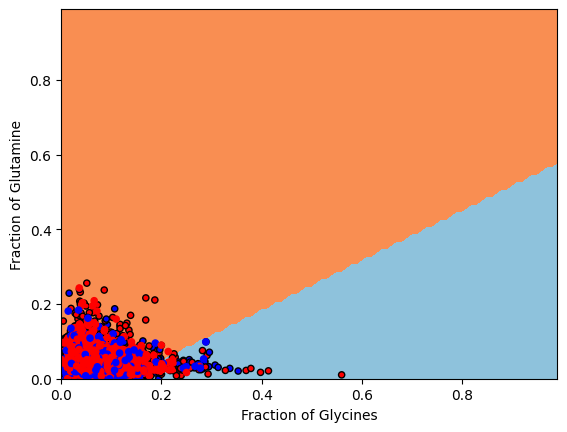

In [5]:
# Let's look at the decision boundary for a model trained with just two features, G_count and Q_count
#we will plot length feature on the x axis and G_count on the y
from matplotlib.colors import ListedColormap
log_classifier.fit(train_df[["G_frac","Q_frac"]],train_df["stable"])

n_classes = 2
cmap = plt.cm.RdYlBu
plot_step = 0.01  # fine step width for decision surface contours

plt.figure()
x_min, x_max = 0, 1
y_min, y_max = 0, 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
)
Z = log_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=cmap)

#plot training data with black edge
plt.scatter(
            train_df["G_frac"],
            train_df["Q_frac"],
            c=train_df["stable"],
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
)

plt.scatter(
            test_df["G_frac"],
            test_df["Q_frac"],
            c=test_df["stable"],
            cmap=ListedColormap(["r", "y", "b"]),
            s=20,
)
plt.xlabel("Fraction of Glycines")
plt.ylabel("Fraction of Glutamine")

plt.show()

# Random Forest Classifier

Train Balanced Accuracy:    0.9444
Test Balanced Accuracy:    0.5969


C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


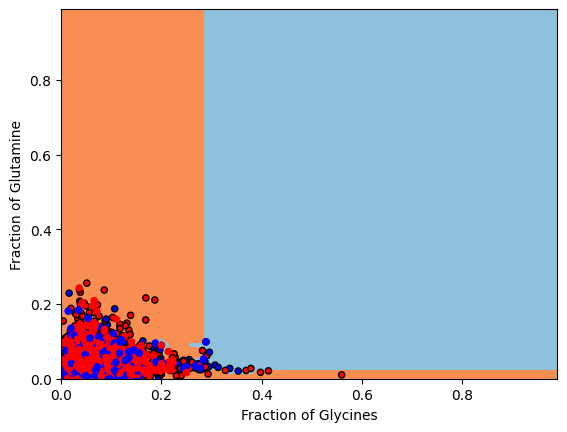

In [6]:
# let's try the same thing with a random forest classifer
# we will skip showing all of the metrics and just focus on balanced accuracy
#try changing n_estimators and seeing how that changes the results
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(n_estimators=10)
random_forest_classifier.fit(train_df[["Q_frac","E_frac","G_frac","Length"]],train_df["stable"])

# Let's calculate metrics for our training data
predicted_train = random_forest_classifier.predict(train_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels
predicted_train_prob = random_forest_classifier.predict_proba(train_df[["Q_frac","E_frac","G_frac","Length"]]) #this will give probabilities

balanced_acc = balanced_accuracy_score(train_df["stable"], predicted_train)
print(f"Train Balanced Accuracy:    {balanced_acc:.4f}")

predicted_test = random_forest_classifier.predict(test_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels
predicted_test_prob = random_forest_classifier.predict_proba(test_df[["Q_frac","E_frac","G_frac","Length"]]) #this will give probabilities

balanced_acc = balanced_accuracy_score(test_df["stable"], predicted_test)
print(f"Test Balanced Accuracy:    {balanced_acc:.4f}")

n_classes = 2
cmap = plt.cm.RdYlBu
plot_step = 0.01  # fine step width for decision surface contours

plt.figure()
#for a plotting decision boundary retrain the model with only two features
random_forest_classifier.fit(train_df[["G_frac","Q_frac"]],train_df["stable"])
x_min, x_max = 0, 1
y_min, y_max = 0, 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
)
Z = random_forest_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z, cmap=cmap)

#plot training data with black edge
plt.scatter(
            train_df["G_frac"],
            train_df["Q_frac"],
            c=train_df["stable"],
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
)
plt.scatter(
            test_df["G_frac"],
            test_df["Q_frac"],
            c=test_df["stable"],
            cmap=ListedColormap(["r", "y", "b"]),
            s=20,
)
plt.xlabel("Fraction of Glycines")
plt.ylabel("Fraction of Glutamine")

plt.show()


# Support Vector Machine Classifier

In [7]:
from sklearn.svm import SVC

# now we will try classification with a support vector classifer, again we will just compare train and test accuracy to save time
# some details on SVC hyperparameters. C is a hyperparameter that controls trade off between training error and decision boundary width/simplicity
# the kernel defines the possible shape of the decision boundary, it applies a transformation to the data (if you use poly as the kernel, you can also set the degree of the polynomial)
# the gamma parameter controls the effect of support vectors on the decision boundary
# if we want to be able to calcualte probabilities to do ROC curves, you need to add a probability=True argument
# SVC is slower than the other classifiers so we will just train it on the beginning of the dataset as an example
svc = SVC(C=1.0, kernel='linear', gamma='scale')
svc.fit(train_df[["Q_frac","E_frac","G_frac","Length"]][0:100],train_df["stable"][0:100])

# Let's calculate metrics for our training data
predicted_train = svc.predict(train_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels

balanced_acc = balanced_accuracy_score(train_df["stable"], predicted_train)
print(f"Train Balanced Accuracy:    {balanced_acc:.4f}")

predicted_test = svc.predict(test_df[["Q_frac","E_frac","G_frac","Length"]]) #this will predict class labels

balanced_acc = balanced_accuracy_score(test_df["stable"], predicted_test)
print(f"Test Balanced Accuracy:    {balanced_acc:.4f}")


Train Balanced Accuracy:    0.5000
Test Balanced Accuracy:    0.5000


# Hyperparameter optimization

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

#recreate the random forest classifier without any hyperparameters set
random_forest_classifier = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

#define the grid of parameters you want to test the combinations of
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]  # helpful if imbalanced
}

#set cross validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#set up the grid,we need to give it our classifier, our grid, scoring, and cross validation method 
grid = GridSearchCV(
    estimator=random_forest_classifier,
    param_grid=param_grid,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc",
        "auprc": "average_precision"
    },
    refit="auprc",      # refit best model based on AUPRC
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# fit the training data - cross validation is also slow so we will run a subset of the dat
grid.fit(train_df[["Q_frac","E_frac","G_frac","Length"]][0:1000], train_df["stable"][0:1000])

# best model
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV AUPRC:")
print(grid.best_score_)

best_model = grid.best_estimator_

#evaluate on train data
y_pred = best_model.predict(train_df[["Q_frac","E_frac","G_frac","Length"]])
y_proba = best_model.predict_proba(train_df[["Q_frac","E_frac","G_frac","Length"]])[:, 1]

print("\nTest Classification Report:")
print(classification_report(train_df["stable"], y_pred))

print("Test ROC AUC:", roc_auc_score(train_df["stable"], y_proba))
print("Test AUPRC:", average_precision_score(train_df["stable"], y_proba))

#evaluate on test data 
y_pred = best_model.predict(test_df[["Q_frac","E_frac","G_frac","Length"]])
y_proba = best_model.predict_proba(test_df[["Q_frac","E_frac","G_frac","Length"]])[:, 1]

print("\nTest Classification Report:")
print(classification_report(test_df["stable"], y_pred))

print("Test ROC AUC:", roc_auc_score(test_df["stable"], y_proba))
print("Test AUPRC:", average_precision_score(test_df["stable"], y_proba))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best parameters:
{'class_weight': None, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best CV AUPRC:
0.4589441477457193

Test Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.97      0.86     24968
        True       0.64      0.17      0.27      8268

    accuracy                           0.77     33236
   macro avg       0.71      0.57      0.57     33236
weighted avg       0.74      0.77      0.72     33236

Test ROC AUC: 0.6876027851692741
Test AUPRC: 0.46569507633998264

Test Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.97      0.87      6268
        True       0.64      0.17      0.27      2042

    accuracy                           0.77      8310
   macro avg       0.71      0.57      0.57      8310
weighted avg       0.75      0